<div style="padding: 1.2em 1.35em; border-radius: 10px; border: 1px solid #b8b8b8; background: #fffeee; margin-bottom: 1em;">
<div style="font-size: 0.72em; letter-spacing: 0.1em; text-transform: uppercase; color: #666666; margin-bottom: 0.3em;">Brainana</div>
<h1 style="margin: 0 0 0.35em 0; font-size: 1.7em; font-weight: 600; color: #000000; line-height: 1.2; border-bottom: 3px solid #fff999; padding-bottom: 0.35em;">Brainana Lite</h1>
<p style="margin: 0; font-size: 0.98em; color: #666666; line-height: 1.6;">Volumetric T1w pipeline &nbsp;·&nbsp; single-subject &nbsp;·&nbsp; no surfaces &nbsp;·&nbsp; no func</p>
</div>

<div style="padding: 0.9em 1.15em; border-radius: 10px; border: 1px solid #b8b8b8; border-left: 3px solid #fff999; background: #fff; margin-bottom: 1.35em; color: #333333; font-size: 0.94em; line-height: 1.55;">
⚠️ <strong>Note</strong> — Brainana Lite is a lightweight, easy-to-run workflow for quick jobs. It may not match the quality or completeness of the <strong>full Brainana Docker</strong> pipeline (Nextflow, surface reconstruction, full QC suite). If results look off or you need production-grade preprocessing, use the <a href="https://brainana.readthedocs.io/en/stable/installation.html" style="color:rgb(171, 160, 7);">full Brainana Docker release</a>.
</div>

## Processing workflow

<div style="padding: 0.75em 1.1em; border-radius: 10px; border: 1px solid #b8b8b8; background: #fff; margin-bottom: 1.35em; font-size: 0.93em; line-height: 1.8; color: #000000;">
<ol style="margin: 0; padding-left: 1.4em;">
<li>BIDS organization</li>
<li>Synthesis of multiple T1w <span style="color: #666666;">(if needed)</span></li>
<li>Conformation</li>
<li>Brain extraction &amp; tissue segmentation</li>
<li>Bias field correction</li>
<li>Registration to template</li>
<li>Atlas backprojection</li>
</ol>
</div>

## How to run (Google Colab)

<div style="padding: 0.75em 1em; border-radius: 10px; border: 1px solid #b8b8b8; background: #fff; margin-bottom: 1.35em; font-size: 0.93em; line-height: 1.55; color: #000000;">
<p style="margin: 0 0 0.85em 0; color: #333333;">Open this notebook in <strong>Google Colab</strong> (upload, or File → Open notebook → GitHub). Local Jupyter also works — the notebook auto-detects Colab vs local; no mode flag.</p>
<p style="margin: 0 0 0.85em 0;"><span style="font-weight: 600; color: #000000;">1.</span> <strong>Enable GPU</strong> — <span style="color: #333333;">Runtime → Change runtime type → Hardware accelerator: <strong>GPU</strong></span> (recommended; <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">USE_GPU</span> defaults to True). Without a GPU, the pipeline still runs on CPU but is much slower.</p>
<p style="margin: 0 0 0.85em 0;"><span style="font-weight: 600; color: #000000;">2.</span> <strong>Set path</strong> — Edit <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">WORKING_DIR</span> in the next cell. Prefer a <strong>Google Drive</strong> folder so outputs persist across sessions, e.g. <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">/content/drive/MyDrive/BrainanaLite</span> (Drive mounts automatically when the path starts with <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">/content/drive</span>).</p>
<p style="margin: 0 0 0.55em 0;"><span style="font-weight: 600; color: #000000;">3.</span> <strong>Prepare data</strong> — In the <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">WORKING_DIR</span> you set in step 2, create a folder named <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">input_T1w</span> (<span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">WORKING_DIR/input_T1w/</span>) and upload your T1w NIfTIs there.</p>
<ul style="margin: 0 0 0.85em 1.15em; padding-left: 2em; color: #333333;">
<li>One file — used as-is; multiple files — the pipeline <strong>synthesizes</strong> them into one volume first.</li>
<li>Any filenames; only <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">.nii</span> or <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">.nii.gz</span> matters.</li>
<li><strong>Google Drive on Colab:</strong> wait until uploads finish (Drive Desktop shows <em>Sync complete</em>). The notebook validates NIfTI bytes, retries slow sync, runs on local disk, and syncs results back to <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">WORKING_DIR</span> when done.</li>
</ul>
<p style="margin: 0 0 0.55em 0;"><span style="font-weight: 600; color: #000000;">4.</span> <strong>Run All</strong> — Creates the environment, runs preprocessing, and displays QC snapshots.</p>
<ul style="margin: 0 0 0.85em 1.15em; padding-left: 2em; color: #333333;">
<li><strong>First run only:</strong> after installing packages, the environment-setup cell <strong>restarts the kernel on purpose</strong> — you’ll see a <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">SystemExit</span> / “restarting” message (<strong>expected, not an error</strong>).</li>
<li>When it comes back, just <strong>Run All again</strong>: the second pass reuses the installed env (no reinstall, no restart) and continues into the import cell.</li>
</ul>
</div>

## Directory layout

<p style="margin: 0 0 0.6em 0; font-size: 0.9em; color: #666666;">Except <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">input_T1w/</span>, the notebook generates everything else under <span style="font-family: ui-monospace, Menlo, monospace; font-size: 0.92em; font-weight: 500; color: #000000; background: #fffddd; border: 1px solid #b8b8b8; border-radius: 4px; padding: 0.1em 0.38em;">WORKING_DIR/</span>.</p>

<div style="border-radius: 10px; border: 1px solid #b8b8b8; overflow: hidden; font-size: 0.88em;">
<div style="padding: 0.45em 1em; background: #fffddd; border-bottom: 1px solid #b8b8b8; font-family: ui-monospace, Menlo, monospace; font-weight: 600; color: #000000;">WORKING_DIR/</div>
<div style="padding: 0.4em 1em; border-bottom: 1px solid #d0d0d0; font-family: ui-monospace, Menlo, monospace; color: #000000; background: #fff;"><span style="color: #8a8a8a;">├──</span> input_T1w/ <span style="font-family: sans-serif; color: #666666;">· your T1w input</span></div>
<div style="padding: 0.4em 1em; border-bottom: 1px solid #d0d0d0; font-family: ui-monospace, Menlo, monospace; color: #000000; background: #fff;"><span style="color: #8a8a8a;">├──</span> input_bids/ <span style="font-family: sans-serif; color: #666666;">· generated BIDS layout</span></div>
<div style="padding: 0.4em 1em; border-bottom: 1px solid #d0d0d0; font-family: ui-monospace, Menlo, monospace; color: #000000; background: #fff;"><span style="color: #8a8a8a;">├──</span> brainana_lite_output/ <span style="font-family: sans-serif; color: #666666;">· preproced, work, QC figures</span></div>
<div style="padding: 0.4em 1em; font-family: ui-monospace, Menlo, monospace; color: #000000; background: #fff;"><span style="color: #8a8a8a;">└──</span> brainana_lite_env/ <span style="font-family: sans-serif; color: #666666;">· local only · brainana env, built on first run</span></div>
</div>

In [1]:
# USER SETTINGS — edit WORKING_DIR, then Run All
# input_T1w/: one or more T1w NIfTIs (.nii/.nii.gz). 1 file = as-is; 2+ = synthesized.
# Also created: input_bids/, brainana_lite_output/ (+ brainana_lite_env/ locally).
# Colab: e.g. "/content/drive/MyDrive/BrainanaLite"
WORKING_DIR = ""   # <-- EDIT THIS

# Pipeline settings
SUBJECT_ID = "01"   # without "sub-" prefix
SESSION_ID = None      # e.g. "01" or None
TEMPLATE   = "NMT2Sym" # NMT2Sym | NMT2Asym | MEBRAINS | Yerkes19 | D99
USE_GPU    = True  # True | False
VERBOSE    = False  # True | False

# brainana git ref when not already installed (branch, tag, or commit). Ignored if importable.
BRAINANA_REF = "feat/brainana_lite"


In [2]:
# Python >=3.11 required (fail fast — older Python gives confusing uv errors later)
import os
import platform
import sys

if sys.version_info < (3, 11):
    raise RuntimeError(
        f"brainana requires Python >=3.11, but this kernel is {sys.version.split()[0]}.\n"
        "  - Local: recreate the venv with a newer Python, e.g. `uv venv .venv --python 3.11`.\n"
        "  - Colab: the runtime's Python is too old for brainana; there is no in-notebook fix."
    )

# Intel Mac (x86_64) unsupported — no torch>=2.3 wheel. Use Colab, Linux, or Apple Silicon.
if sys.platform == "darwin" and platform.machine() == "x86_64":
    raise RuntimeError(
        "Intel (x86_64) macOS is not supported by Brainana Lite.\n"
        "  The stack requires torch>=2.3 / numpy>=2.3 / fireants==1.5.0, and PyTorch ships no\n"
        "  Intel-Mac build for >=2.3 (last was 2.2.2), so it cannot install here — on CPU or GPU.\n"
        "  Run the notebook on one of:\n"
        "    - Google Colab (this notebook is Colab-ready; free, no local setup) — recommended;\n"
        "    - a Linux machine (ideally with an NVIDIA GPU for speed); or\n"
        "    - an Apple Silicon (arm64) Mac."
    )

_env_bits = [f"interpreter: {sys.executable}"]
if venv := os.environ.get("VIRTUAL_ENV"):
    _env_bits.append(f"venv: {venv}")
elif sys.prefix != getattr(sys, "base_prefix", sys.prefix):
    _env_bits.append(f"venv: {sys.prefix}")
if conda := os.environ.get("CONDA_DEFAULT_ENV"):
    _env_bits.append(f"conda: {conda}")
if os.environ.get("COLAB_RELEASE_TAG"):
    _env_bits.append("runtime: Google Colab")

print(f"Python {sys.version.split()[0]} OK (>=3.11).")
print("Environment:", " · ".join(_env_bits))


Python 3.11.8 OK (>=3.11).
Environment: interpreter: /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/.venv/bin/python3 · venv: /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/.venv · conda: base


In [3]:
# ENVIRONMENT SETUP — clone brainana, install deps, import pipeline. No edits needed.

import os
import re
import shutil
import subprocess
import sys
import logging
import importlib.util
import time
from pathlib import Path

_step_times: dict[str, float] = {}
_step_stack: list[str] = []


def _format_duration(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.1f}s"
    minutes, secs = divmod(seconds, 60)
    if minutes < 60:
        return f"{int(minutes)}m {secs:.0f}s"
    hours, minutes = divmod(minutes, 60)
    return f"{int(hours)}h {int(minutes)}m {secs:.0f}s"


def _step_indent(depth: int | None = None) -> str:
    if depth is None:
        depth = max(0, len(_step_stack) - 1)
    return "  " * depth


def _step_detail_lines(detail: str, indent: str) -> list[str]:
    if not detail:
        return []
    sub = indent + "  "
    return [sub + line if line else "" for line in detail.splitlines()]


def step_log(name: str, *, done: bool = False, detail: str = "") -> None:
    """Print step start/finish with hierarchy, icons, and elapsed time."""
    if done:
        duration = ""
        if name in _step_times:
            duration = _format_duration(time.perf_counter() - _step_times.pop(name))
        depth = max(0, len(_step_stack) - 1)
        if _step_stack and _step_stack[-1] == name:
            _step_stack.pop()
        indent = _step_indent(depth)
        line = f"{indent}✓ {name}"
        if duration:
            line += f"  ·  {duration}"
        lines = [line, *_step_detail_lines(detail, indent)]
        print("\n".join(lines), flush=True)
        if depth == 0 and re.match(r"^Step [1-9]", name):
            print(flush=True)
    else:
        if not _step_stack and re.match(r"^Step [1-9]", name):
            print(flush=True)
        depth = len(_step_stack)
        _step_stack.append(name)
        _step_times[name] = time.perf_counter()
        print(f"{_step_indent(depth)}▶ {name}", flush=True)


def tea_time(hint: str = "") -> None:
    """Print a friendly note before a long-running step."""
    msg = "This might take a few minutes — tea time!"
    if hint:
        msg = f"{hint} {msg}"
    print(f"{_step_indent()}  ☕ {msg}", flush=True)


BRAINANA_URL  = "https://github.com/xingyu-liu/brainana.git"
FIREANTS_URL  = "https://github.com/rohitrango/FireANTs.git"
FIREANTS_REF  = "v1.5.0"   # fused_ops built from source; base fireants comes from brainana deps

try:
    import google.colab  # noqa: F401
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

# Warn if local Jupyter uses system Python (installs mutate the active kernel env).
_in_venv = sys.prefix != sys.base_prefix
_conda_env = os.environ.get("CONDA_DEFAULT_ENV", "")
ISOLATED_ENV = _in_venv or (_conda_env not in ("", "base"))
if (not IS_COLAB) and (not ISOLATED_ENV):
    print("WARNING: this kernel runs in a non-isolated (system/base) Python; installs here may")
    print("         pollute it. Recommended — launch Jupyter from an isolated env first, e.g.:")
    print("           uv venv .venv && source .venv/bin/activate \\")
    print("             && uv pip install jupyterlab && jupyter lab")
    print("         Continuing anyway.\n")

WORKING_DIR = Path(WORKING_DIR)
INPUT_DIR  = WORKING_DIR / "input_T1w"            # user T1w NIfTIs
BIDS_DIR   = WORKING_DIR / "input_bids"           # generated BIDS
OUTPUT_DIR = WORKING_DIR / "brainana_lite_output" # outputs / work / QC

# Colab + Google Drive FUSE: directory entries appear before file bytes finish syncing.
ON_DRIVE_FUSE = IS_COLAB and str(WORKING_DIR).startswith("/content/drive")
if ON_DRIVE_FUSE:
    from google.colab import drive
    drive.mount("/content/drive")

import gzip

DRIVE_NIFTI_TIMEOUT = 120  # seconds to wait for Drive upload + FUSE hydration
DRIVE_NIFTI_POLL = 3


def wait_for_real_nifti(path, *, timeout=DRIVE_NIFTI_TIMEOUT, poll=DRIVE_NIFTI_POLL):
    """Force FUSE hydration and verify the file is a readable NIfTI (not a placeholder)."""
    path = Path(path)
    deadline = time.monotonic() + timeout
    last = None
    while time.monotonic() < deadline:
        try:
            with open(path, "rb") as f:
                head = f.read(2)
            if len(head) < 2:
                last = "zero/short read (not hydrated yet)"
            elif path.name.endswith(".nii.gz"):
                if head != b"\x1f\x8b":
                    last = f"bad gzip magic {head!r} (placeholder/partial sync?)"
                else:
                    with gzip.open(path, "rb") as g:
                        g.read(352)  # NIfTI-1 header; raises if truncated
                    return
            else:
                with open(path, "rb") as f:
                    hdr = f.read(348)
                if len(hdr) < 348:
                    last = "truncated uncompressed NIfTI"
                else:
                    return
        except OSError as exc:
            last = f"read error: {exc}"
        except Exception as exc:
            last = str(exc)
        print(f"  …waiting for file to sync: {path.name} ({last})")
        time.sleep(poll)
    raise TimeoutError(
        f"{path} never became a valid NIfTI ({last}). "
        "On Colab+Drive: wait for Drive Desktop 'Sync complete' before Run All."
    )


def copy_nifti_validated(src: Path, dst: Path) -> None:
    wait_for_real_nifti(src)
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    wait_for_real_nifti(dst)


# Clone target: Colab=/content (ephemeral); local=WORKING_DIR/brainana_lite_env (persistent).
ENV_DIR = Path("/content") if IS_COLAB else (WORKING_DIR / "brainana_lite_env")
BRAINANA_DIR = ENV_DIR / "brainana"
FIREANTS_DIR = ENV_DIR / "fireants"

def _installed(mod: str) -> bool:
    try:
        return importlib.util.find_spec(mod) is not None
    except Exception:
        return False

def _uv_cmd() -> list:
    """Return uv (bootstrap if missing). brainana needs uv for pinned deps + overrides."""
    uv = shutil.which("uv")
    if uv:
        return [uv]
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
    uv = shutil.which("uv")
    return [uv] if uv else [sys.executable, "-m", "uv"]


LITE_TEMPLATE_RES = "res-05"  # matches config template.output_space

# fastsurfer_nn fix_V1_WM (defaults.yaml) always resolves these under NMT2Sym, regardless of TEMPLATE.
_NMT2SYM_FIX_V1_DIR = "template_zoo/template/NMT2Sym/"
_FASTSURFER_FIX_V1_TPL_SUFFIXES = (
    "tpl-NMT2Sym_res-05_T1w_brain.nii.gz",
    "tpl-NMT2Sym_res-05_T1w_WM_V1.nii.gz",
)
_FASTSURFER_FIX_V1_ATLAS_SUFFIX = "atlas-ARM2_space-NMT2Sym_res-05.nii.gz"


def _paths_with_suffix(listing: list[str], suffix: str, *, prefix: str = "") -> list[str]:
    return [p for p in listing if p.startswith(prefix) and p.endswith(suffix)]


def _lite_template_zoo_paths(repo: Path, template: str, res: str) -> list[str]:
    """Paths under template_zoo/ to fetch for lite: one brain template + atlases in space."""
    listing = subprocess.run(
        ["git", "-C", str(repo), "ls-tree", "-r", "--name-only", "HEAD"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.splitlines()
    tpl_dir = f"template_zoo/template/{template}/"
    space_tag = f"_space-{template}_{res}"
    tpl_paths = [
        p
        for p in listing
        if p.startswith(tpl_dir) and res in p and p.endswith("_brain.nii.gz")
    ]
    atlas_paths = [
        p
        for p in listing
        if p.startswith("template_zoo/atlas/")
        and space_tag in p
        and p.endswith(".nii.gz")
    ]
    fix_v1_tpl_paths: list[str] = []
    for suffix in _FASTSURFER_FIX_V1_TPL_SUFFIXES:
        matches = _paths_with_suffix(listing, suffix, prefix=_NMT2SYM_FIX_V1_DIR)
        if not matches:
            matches = [p for p in listing if p.endswith(suffix)]
        fix_v1_tpl_paths.extend(matches)
    fix_v1_atlas = _paths_with_suffix(listing, _FASTSURFER_FIX_V1_ATLAS_SUFFIX, prefix="template_zoo/atlas/")
    if not fix_v1_atlas:
        fix_v1_atlas = [p for p in listing if p.endswith(_FASTSURFER_FIX_V1_ATLAS_SUFFIX)]
    if not tpl_paths:
        raise RuntimeError(
            f"No template brain volume found for {template}:{res} "
            f"(expected tpl-{template}_{res}_*_brain.nii.gz under {tpl_dir})."
        )
    all_tpl = tpl_paths + fix_v1_tpl_paths
    missing_fix_v1 = [
        s for s in _FASTSURFER_FIX_V1_TPL_SUFFIXES if not any(p.endswith(s) for p in all_tpl)
    ]
    if missing_fix_v1:
        raise RuntimeError(
            "fastsurfer_nn fix_V1_WM requires NMT2Sym templates missing from repo: "
            + ", ".join(missing_fix_v1)
            + f". Check BRAINANA_REF (current tree at {repo})."
        )
    return list(dict.fromkeys(tpl_paths + atlas_paths + fix_v1_tpl_paths + fix_v1_atlas))


def _sparse_checkout_brainana_lite(repo: Path, ref: str, template: str, res: str) -> None:
    """Clone metadata only, then checkout code + lite template_zoo (not the full zoo)."""
    subprocess.run(
        ["git", "clone", "--filter=blob:none", "--sparse", "--no-checkout", "--quiet",
         BRAINANA_URL, str(repo)],
        check=True,
    )
    subprocess.run(["git", "-C", str(repo), "checkout", "--quiet", ref], check=True)
    code_paths = [
        p for p in subprocess.run(
            ["git", "-C", str(repo), "ls-tree", "-r", "--name-only", "HEAD"],
            capture_output=True,
            text=True,
            check=True,
        ).stdout.splitlines()
        if p and not p.startswith("template_zoo/")
    ]
    zoo_paths = _lite_template_zoo_paths(repo, template, res)
    subprocess.run(
        ["git", "-C", str(repo), "sparse-checkout", "init", "--no-cone"],
        check=True,
    )
    subprocess.run(
        ["git", "-C", str(repo), "sparse-checkout", "set", "--stdin"],
        input="\n".join(code_paths + zoo_paths),
        text=True,
        check=True,
    )
    n_tpl = sum(1 for p in zoo_paths if p.startswith("template_zoo/template/"))
    n_atlas = len(zoo_paths) - n_tpl
    print(
        f"template_zoo (lite): {n_tpl} brain template ({template}:{res}), "
        f"{n_atlas} atlas file(s) in {template} space"
    )


# Clone + install brainana. Idempotent: when BRAINANA_DIR is already checked out at
# BRAINANA_REF with deps present, the slow re-clone/re-install is skipped. Set
# FORCE_REINSTALL=True to pull the latest branch commits or rebuild a broken env.
FORCE_REINSTALL = False


def _clone_is_current(repo: Path, ref: str) -> bool:
    """True if `repo` is a brainana clone already checked out at `ref`."""
    if not (repo / "src").exists():
        return False
    try:
        branch = subprocess.run(
            ["git", "-C", str(repo), "rev-parse", "--abbrev-ref", "HEAD"],
            capture_output=True, text=True, check=True,
        ).stdout.strip()
        head = subprocess.run(
            ["git", "-C", str(repo), "rev-parse", "HEAD"],
            capture_output=True, text=True, check=True,
        ).stdout.strip()
    except Exception:
        return False  # not a git repo / git missing -> treat as not current
    return ref in (branch, head) or head.startswith(ref)


step_log("Environment setup")
print(f"{'Colab' if IS_COLAB else 'Local'} run. WORKING_DIR: {WORKING_DIR}")
if ON_DRIVE_FUSE:
    print(f"  Drive FUSE detected — processing on {PROCESS_DIR} (sync back when done).")
ENV_DIR.mkdir(parents=True, exist_ok=True)

# antspyx ("ants") + torch are the heavy deps brainana[lite] pulls in; their presence,
# a matching clone ref, and no FORCE_REINSTALL together mean the env is already built.
_env_ready = (
    not FORCE_REINSTALL
    and _clone_is_current(BRAINANA_DIR, BRAINANA_REF)
    and _installed("ants")
    and _installed("torch")
)

step_log("Clone and install brainana (uv)")
if _env_ready:
    step_log(
        "Clone and install brainana (uv)", done=True,
        detail=f"reused existing env (ref={BRAINANA_REF}); set FORCE_REINSTALL=True to refresh",
    )
else:
    tea_time("Installing brainana and dependencies.")
    if BRAINANA_DIR.exists():
        shutil.rmtree(BRAINANA_DIR)  # drop stale clone
    # Sparse checkout: code + selected template_zoo for TEMPLATE only.
    _sparse_checkout_brainana_lite(BRAINANA_DIR, BRAINANA_REF, TEMPLATE, LITE_TEMPLATE_RES)
    # Colab: install SuiteSparse headers for scikit-sparse build.
    if IS_COLAB:
        print("Ensuring SuiteSparse headers (libsuitesparse-dev) on Colab...")
        subprocess.run(["apt-get", "install", "-y", "-qq", "libsuitesparse-dev"], check=False)
    # uv install from BRAINANA_DIR (uses [tool.uv] overrides). UV_TORCH_BACKEND picks a compatible torch wheel.
    _torch_backend = "cpu" if sys.platform == "darwin" else "auto"
    _uv_env = {**os.environ, "UV_TORCH_BACKEND": _torch_backend}
    uv_extra = [] if (sys.prefix != sys.base_prefix) else ["--system"]
    try:
        # Live uv output; on failure read the lines above the traceback.
        subprocess.run([*_uv_cmd(), "pip", "install", *uv_extra,
                        "--python", sys.executable, "-e", f"{BRAINANA_DIR}[lite]"],
                       cwd=str(BRAINANA_DIR), env=_uv_env, check=True)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            f"uv failed to install brainana[lite] (exit {exc.returncode}). The real cause is in\n"
            "uv's output printed just ABOVE this message - read it first. Common causes:\n"
            "  - A dependency has no wheel for this OS/CPU (look for 'No solution found' or\n"
            "    'no matching distribution'; e.g. torch has no Intel-macOS build - unsupported).\n"
            "  - A source build failed for missing system headers/compilers.\n"
            "  - Network/proxy trouble reaching PyPI."
        ) from exc
    step_log("Clone and install brainana (uv)", done=True, detail=f"ref={BRAINANA_REF}, dir={BRAINANA_DIR}")

# Editable install: ensure the clone's src/ is importable in this kernel (also after a restart).
_src_dir = str(BRAINANA_DIR / "src")
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)
importlib.invalidate_caches()

# --- Stale binary-dependency guard (numpy/scipy/torch can't hot-swap in a live kernel) ---
# Colab boots with numpy already imported. If uv just upgraded numpy (or scipy/torch) on
# disk, the in-memory compiled C extension no longer matches the on-disk Python files, and
# the very next import surfaces a cryptic ImportError deep in numpy/scipy
# (e.g. "cannot import name '_center' from numpy._core.umath"). The sys.path trick above
# fixes brainana's pure-Python src/ but CANNOT swap a binary dep in a running kernel.
# Detect the mismatch now and restart the runtime so the new versions load cleanly.
import importlib.metadata as _ilm

_BINARY_DEPS = ("numpy", "scipy", "torch", "pandas", "matplotlib")
_stale_deps = []
for _dep in _BINARY_DEPS:
    _loaded_mod = sys.modules.get(_dep)
    if _loaded_mod is None:
        continue  # not yet imported -> will load the fresh on-disk version, no conflict
    _loaded_ver = getattr(_loaded_mod, "__version__", None)
    try:
        _disk_ver = _ilm.version(_dep)
    except _ilm.PackageNotFoundError:
        continue
    if _loaded_ver and _disk_ver and _loaded_ver != _disk_ver:
        _stale_deps.append(f"{_dep} {_loaded_ver}->{_disk_ver}")

if _stale_deps:
    _summary = ", ".join(_stale_deps)
    print("\n" + "=" * 72)
    print("\u26a0  Binary dependencies were upgraded under the running kernel:")
    print(f"     {_summary}")
    print("   numpy/scipy/torch load compiled C extensions that CANNOT be swapped in a")
    print("   live kernel. Continuing would raise a cryptic ImportError deep inside")
    print("   numpy/scipy (e.g. \"cannot import name '_center'\").")
    if IS_COLAB:
        print("   -> Restarting the runtime now. When it returns, just run")
        print("      'Runtime > Run all' again (re-clone/re-install is fast & idempotent).")
        print("=" * 72, flush=True)
        try:
            get_ipython().kernel.do_shutdown(restart=True)  # clean Colab runtime restart
        except Exception:
            os._exit(0)  # fallback: force the kernel to restart
        raise SystemExit("Restarting kernel to load upgraded binary deps - re-run Run All.")
    print("   -> Restart the Jupyter kernel (Kernel > Restart), then Run All again.")
    print("=" * 72, flush=True)
    raise RuntimeError(
        "Binary deps upgraded under the running kernel (" + _summary + "). "
        "Restart the kernel and Run All again."
    )

# Optional FireANTs CUDA fused_ops (BUILD_FUSED_OPS).
# optional CUDA speedup; compiles from source (needs nvcc, adds setup time).
BUILD_FUSED_OPS = False

step_log("FireANTs fused_ops (optional CUDA build)")
try:
    import torch
    if not BUILD_FUSED_OPS:
        step_log("FireANTs fused_ops (optional CUDA build)", done=True,
                 detail="skipped (BUILD_FUSED_OPS=False; non-fused GPU path used)")
    elif torch.cuda.is_available() and _installed("fireants"):
        if not FIREANTS_DIR.exists():
            subprocess.run(["git", "clone", "--quiet", "--branch", FIREANTS_REF, "--depth", "1",
                            FIREANTS_URL, str(FIREANTS_DIR)], check=True)
        fused = FIREANTS_DIR / "fused_ops"
        if fused.exists():
            subprocess.run([sys.executable, str(fused / "setup.py"), "build_ext", "install"],
                           cwd=str(fused), check=False)
            step_log("FireANTs fused_ops (optional CUDA build)", done=True)
        else:
            step_log("FireANTs fused_ops (optional CUDA build)", done=True, detail="fused_ops not found; skipped")
    else:
        step_log("FireANTs fused_ops (optional CUDA build)", done=True, detail="no CUDA or fireants; skipped")
except Exception as exc:
    step_log("FireANTs fused_ops (optional CUDA build)", done=True, detail=f"skipped ({exc})")

# Lite uses antspyx for all ANTs ops — no ANTs CLI required.

# Verify antspyx is available (from brainana[lite]).
if not _installed("ants"):
    raise RuntimeError(
        "Lite requires the antspyx (`ants`) package, but it is not importable.\n"
        "Ensure the brainana[lite] extra pulled in antspyx, then restart the kernel and Run All."
    )
print("Using antspyx backend for all ANTs ops (RIGID_METHOD=sitk).")

# Patch QC module so surface-recon import is optional.
snapshots_py = BRAINANA_DIR / "src/nhp_mri_prep/quality_control/snapshots.py"
if snapshots_py.exists():
    text = snapshots_py.read_text()
    old = "from fastsurfer_surfrecon.io.surface import convert_fs_surface_to_gifti"
    new = (
        "try:\n    from fastsurfer_surfrecon.io.surface import convert_fs_surface_to_gifti\n"
        "except Exception:\n    convert_fs_surface_to_gifti = None"
    )
    if old in text and "convert_fs_surface_to_gifti = None" not in text:
        snapshots_py.write_text(text.replace(old, new))
        print("Patched snapshots.py for lite QC imports.")

step_log("Environment setup", done=True)


▶ Environment setup
Local run. WORKING_DIR: /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy
  ▶ Clone and install brainana (uv)
  ✓ Clone and install brainana (uv)  ·  0.0s
    reused existing env (ref=feat/brainana_lite); set FORCE_REINSTALL=True to refresh
  ▶ FireANTs fused_ops (optional CUDA build)
  ✓ FireANTs fused_ops (optional CUDA build)  ·  0.9s
    skipped (BUILD_FUSED_OPS=False; non-fused GPU path used)
Using antspyx backend for all ANTs ops (RIGID_METHOD=sitk).
✓ Environment setup  ·  0.9s


In [4]:
# IMPORTS - load the brainana pipeline into this kernel. Fast & re-runnable;
# run the environment-setup cell above first (it builds the env and defines BRAINANA_DIR).
#
# First run only: the environment-setup cell restarts the kernel after installing
# packages (you'll see a SystemExit / "restarting" message - expected, not an error).
# Just Run All again; the second pass reuses the env (no restart) and reaches this cell.
if "BRAINANA_DIR" not in globals():
    raise RuntimeError(
        "Run the environment-setup cell above first "
        "(it clones brainana, installs deps, and defines BRAINANA_DIR)."
    )

step_log("Load brainana pipeline")

from IPython.display import Image, display

from nhp_mri_prep.utils.logger import setup_logging, get_logger

_LOG_LEVEL = logging.INFO if VERBOSE else logging.WARNING
setup_logging(level=_LOG_LEVEL)
qc_logger = get_logger("brainana_lite_qc")

# Unify FireANTs log format via root handler (before fireants import).
_root_logger = logging.getLogger()
if not any(getattr(h, "_brainana_unified", False) for h in _root_logger.handlers):
    _unified_handler = logging.StreamHandler()
    _unified_handler.setFormatter(get_logger().handlers[0].formatter)
    _unified_handler.setLevel(_LOG_LEVEL)
    _unified_handler._brainana_unified = True
    _root_logger.addHandler(_unified_handler)
_root_logger.setLevel(_LOG_LEVEL)

from nhp_mri_prep.config import load_config
from nhp_mri_prep.steps.types import StepInput
from nhp_mri_prep.steps.anatomical import (
    anat_synthesis,
    anat_conform,
    anat_skullstripping,
    anat_bias_correction,
    anat_registration,
    anat_backproject_atlases,
    anat_reproject_atlases_to_scanner,
)
from nhp_mri_prep.operations.registration import ants_apply_transforms
from nhp_mri_prep.operations.antspyx_ops import set_ants_backend

set_ants_backend("antspyx")  # lite: antspyx only
from nhp_mri_prep.utils.templates import resolve_template
from nhp_mri_prep.utils.bids import (
    create_bids_output_filename,
    create_synthesized_bids_filename,
    get_filename_stem,
    replace_bids_space,
)
from nhp_mri_prep.utils.nextflow import create_output_link, detect_modality
from nhp_mri_prep.quality_control import (
    create_conform_qc,
    create_skullstripping_qc,
    create_bias_correction_qc,
    create_registration_qc,
    create_atlas_segmentation_qc,
)

BIDS_PREFIX = f"sub-{SUBJECT_ID}"
if SESSION_ID:
    BIDS_PREFIX += f"_ses-{SESSION_ID}"

def subject_deriv_dir() -> Path:
    base = OUTPUT_DIR / "preproced" / f"sub-{SUBJECT_ID}"
    return base / f"ses-{SESSION_ID}" / "anat" if SESSION_ID else base / "anat"

def subject_fig_dir() -> Path:
    base = OUTPUT_DIR / "preproced" / f"sub-{SUBJECT_ID}"
    return base / f"ses-{SESSION_ID}" / "figures" if SESSION_ID else base / "figures"

ANAT_DIR = subject_deriv_dir()
FIG_DIR = subject_fig_dir()
WORK_ROOT = OUTPUT_DIR / "work"
ANAT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
WORK_ROOT.mkdir(parents=True, exist_ok=True)

print(f"INPUT_DIR:  {INPUT_DIR}")
print(f"BIDS_DIR:   {BIDS_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"ANAT_DIR:   {ANAT_DIR}")
print(f"FIG_DIR:    {FIG_DIR}")
print(f"Log level:  {'INFO' if VERBOSE else 'WARNING'} (VERBOSE={VERBOSE})")

step_log("Load brainana pipeline", done=True)


▶ Load brainana pipeline


/mnt/DataDrive3/xliu/prep_test/test_brainana_lite/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INPUT_DIR:  /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy/input_T1w
BIDS_DIR:   /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy/input_bids
OUTPUT_DIR: /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy/brainana_lite_output
ANAT_DIR:   /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy/brainana_lite_output/preproced/sub-01/anat
FIG_DIR:    /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy/brainana_lite_output/preproced/sub-01/figures
Log level:  WARNING (VERBOSE=False)
✓ Load brainana pipeline  ·  1.6s


In [5]:
# GPU check — USE_GPU requests GPU; pipeline falls back to CPU if none visible.
# Colab: enable GPU via Runtime -> Change runtime type -> GPU, then Run All.
import torch

if USE_GPU and not torch.cuda.is_available():
    print("WARNING: USE_GPU=True but PyTorch sees no CUDA GPU -> running on CPU (slower).")
    print("         Colab: Runtime -> Change runtime type -> GPU, then Run All again.")
    print("         Local: check your NVIDIA driver / CUDA-enabled torch build.")
elif USE_GPU:
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
else:
    print("USE_GPU=False -> running on CPU by request.")


GPU available: NVIDIA RTX A6000


In [6]:
# Step 0 — BIDS organization
step_log("Step 0 — BIDS organization")
USER_INPUT_DIR.mkdir(parents=True, exist_ok=True)
INPUT_DIR.mkdir(parents=True, exist_ok=True)

candidates = sorted(
    p for p in USER_INPUT_DIR.iterdir()
    if p.is_file() and (p.name.endswith(".nii.gz") or p.name.endswith(".nii"))
)
if not candidates:
    raise FileNotFoundError(
        f"No NIfTI files found in {USER_INPUT_DIR}. "
        f"Put your T1w .nii/.nii.gz file(s) in this 'input_T1w' folder and re-run."
    )

if ON_DRIVE_FUSE:
    print(f"Staging {len(candidates)} file(s) from Drive to local disk ({INPUT_DIR})…")
    staged = []
    for src in candidates:
        local = INPUT_DIR / src.name
        if src.resolve() != local.resolve():
            copy_nifti_validated(src, local)
        else:
            wait_for_real_nifti(local)
        staged.append(local)
    candidates = sorted(staged)

bids_anat_dir = BIDS_DIR / f"sub-{SUBJECT_ID}"
if SESSION_ID:
    bids_anat_dir = bids_anat_dir / f"ses-{SESSION_ID}"
bids_anat_dir = bids_anat_dir / "anat"
bids_anat_dir.mkdir(parents=True, exist_ok=True)

bids_files = []
print("BIDS input mapping:")
for idx, src in enumerate(candidates, start=1):
    run_tag = f"_run-{idx:02d}" if len(candidates) > 1 else ""
    ses_tag = f"_ses-{SESSION_ID}" if SESSION_ID else ""
    dst_name = f"sub-{SUBJECT_ID}{ses_tag}{run_tag}_T1w.nii.gz"
    dst = bids_anat_dir / dst_name
    if src.resolve() != dst.resolve():
        copy_nifti_validated(src, dst)
    else:
        wait_for_real_nifti(dst)
    bids_files.append(dst)
    rel = dst.relative_to(PROCESS_DIR) if PROCESS_DIR else dst.relative_to(WORKING_DIR)
    print(f"  {src.name} -> {rel}")

bids_name = bids_files[0]
meta = {
    "subject_id": SUBJECT_ID,
    "session_id": SESSION_ID or "",
    "session_count": 1,
}
step_log("Step 0 — BIDS organization", done=True, detail=f"{len(bids_files)} file(s)")


▶ Step 0 — BIDS organization
BIDS input mapping:
  run-1_T1w_.nii.gz -> input_bids/sub-01/anat/sub-01_run-01_T1w.nii.gz
  run-3_T1w___.nii.gz -> input_bids/sub-01/anat/sub-01_run-02_T1w.nii.gz
✓ Step 0 — BIDS organization  ·  0.0s
  2 file(s)


In [7]:
# Config, templates, helpers
config = load_config()
config["anat"]["surface_reconstruction"]["enabled"] = False
config["anat"]["conform"]["rigid_method"] = "sitk"  # lite: SimpleITK rigid conform
config["template"]["output_space"] = f"{TEMPLATE}:{LITE_TEMPLATE_RES}"
config["general"]["gpu_device"] = "auto" if USE_GPU else -1
config["registration"]["fireants_allow_cpu"] = True
config["general"]["anat_only"] = True

effective_output_space = config["template"]["output_space"]
template_file = Path(resolve_template(effective_output_space))

modality = "T1w"
bids_stem = get_filename_stem(bids_name)
bids_prefix_wo_modality = bids_stem.replace(f"_{modality}", "")


def publish_copy(src: Path, filename: str) -> Path:
    dst = ANAT_DIR / filename
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    return dst


def _xfm_ext(path: Path) -> str:
    """Transform file extension (.h5, .nii.gz, etc.)."""
    resolved = Path(path).resolve()
    return "".join(resolved.suffixes) if resolved.suffixes else resolved.suffix


def show_qc(png_path: Path, title: str = "") -> None:
    if title:
        print(title)
    if png_path.exists():
        display(Image(filename=str(png_path)))
    else:
        print(f"QC image not found: {png_path}")

print(f"Template ({TEMPLATE}): {template_file}")


Template (NMT2Sym): /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy/brainana_lite_env/brainana/template_zoo/template/NMT2Sym/tpl-NMT2Sym_res-05_T1w_brain.nii.gz


In [8]:
# Step 1 — Synthesis (multi-run T1w within session)
step_log("Step 1 — Synthesis")
synth_dir = WORK_ROOT / "synthesis"
synth_dir.mkdir(parents=True, exist_ok=True)

synth_out = anat_synthesis(anat_files=bids_files, working_dir=synth_dir, config=config)
synthesized = synth_out.metadata.get("synthesized", False)
is_subject_level = SESSION_ID is None

bids_output_filename, bids_name_downstream = create_synthesized_bids_filename(
    original_file=bids_name,
    modality=modality,
    is_subject_level=is_subject_level,
    synthesized=synthesized,
)

synth_file = synth_out.output_file
scanner_t1w_path = publish_copy(synth_file, bids_output_filename)
step_log(
    "Step 1 — Synthesis",
    done=True,
    detail=f"synthesized={synthesized}, published={scanner_t1w_path.name}",
)
print(f"BIDS downstream template: {bids_name_downstream}")

# downstream BIDS name
bids_name = Path(bids_name_downstream)
bids_stem = get_filename_stem(bids_name)
bids_prefix_wo_modality = bids_stem.replace(f"_{modality}", "")



▶ Step 1 — Synthesis
✓ Step 1 — Synthesis  ·  4.6s
  synthesized=True, published=sub-01_space-scanner_T1w.nii.gz

BIDS downstream template: sub-01/anat/sub-01_T1w.nii.gz



▶ Step 2 — Conform to template
Conform QC


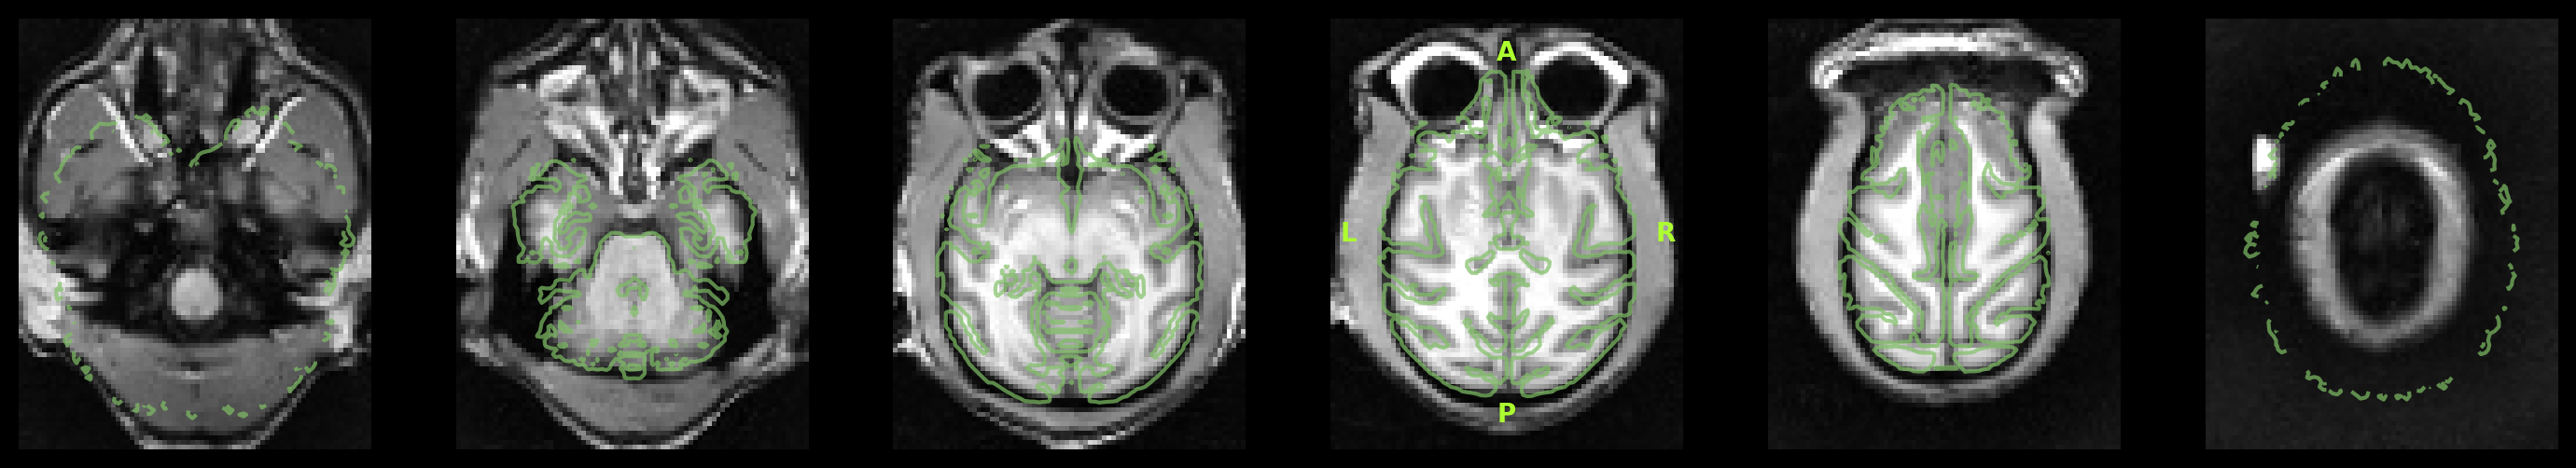

✓ Step 2 — Conform to template  ·  18.9s
  /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy/brainana_lite_output/work/conform/anat_conformed.nii.gz, xfm=sub-01_from-scanner_to-T1w_mode-image_xfm.mat, sub-01_from-T1w_to-scanner_mode-image_xfm.mat



In [9]:
# Step 2 — Conform to template
step_log("Step 2 — Conform to template")
conform_dir = WORK_ROOT / "conform"
conform_dir.mkdir(parents=True, exist_ok=True)

conform_out = anat_conform(
    StepInput(
        input_file=synth_file,
        working_dir=conform_dir,
        config=config,
        output_name="anat_conformed.nii.gz",
        metadata=meta,
    ),
    template_file=template_file,
)

conformed_file = conform_out.output_file

template_resampled = conform_out.additional_files.get("template_resampled", template_file)
conform_qc_png = FIG_DIR / f"{BIDS_PREFIX}_desc-conform_T1w.png"
create_conform_qc(
    conformed_file=str(conformed_file),
    template_file=str(template_resampled),
    save_f=str(conform_qc_png),
    modality="anat",
    logger=qc_logger,
)
show_qc(conform_qc_png, "Conform QC")

# Publish conform .mat affines (scanner <-> T1w).
conform_xfm_published = []
_conform_fwd = conform_out.additional_files.get("forward_transform")
_conform_inv = conform_out.additional_files.get("inverse_transform")
if _conform_fwd:
    _p = publish_copy(
        _conform_fwd,
        f"{bids_prefix_wo_modality}_from-scanner_to-{modality}_mode-image_xfm.mat",
    )
    conform_xfm_published.append(_p.name)
if _conform_inv:
    _p = publish_copy(
        _conform_inv,
        f"{bids_prefix_wo_modality}_from-{modality}_to-scanner_mode-image_xfm.mat",
    )
    conform_xfm_published.append(_p.name)

_conform_detail = str(conformed_file)
if conform_xfm_published:
    _conform_detail += f", xfm={', '.join(conform_xfm_published)}"
step_log("Step 2 — Conform to template", done=True, detail=_conform_detail)



▶ Step 3 — Skull stripping + segmentation


2026-06-02 23:09:11 | WARNING  | Fused operations not available, compile the fused ops to use them
2026-06-02 23:09:11 | WARNING  | fireants_fused_ops not found, will use torch fft instead
2026-06-02 23:09:11 | WARNING  | Fused ops not found, using baseline implementation


Skull stripping QC


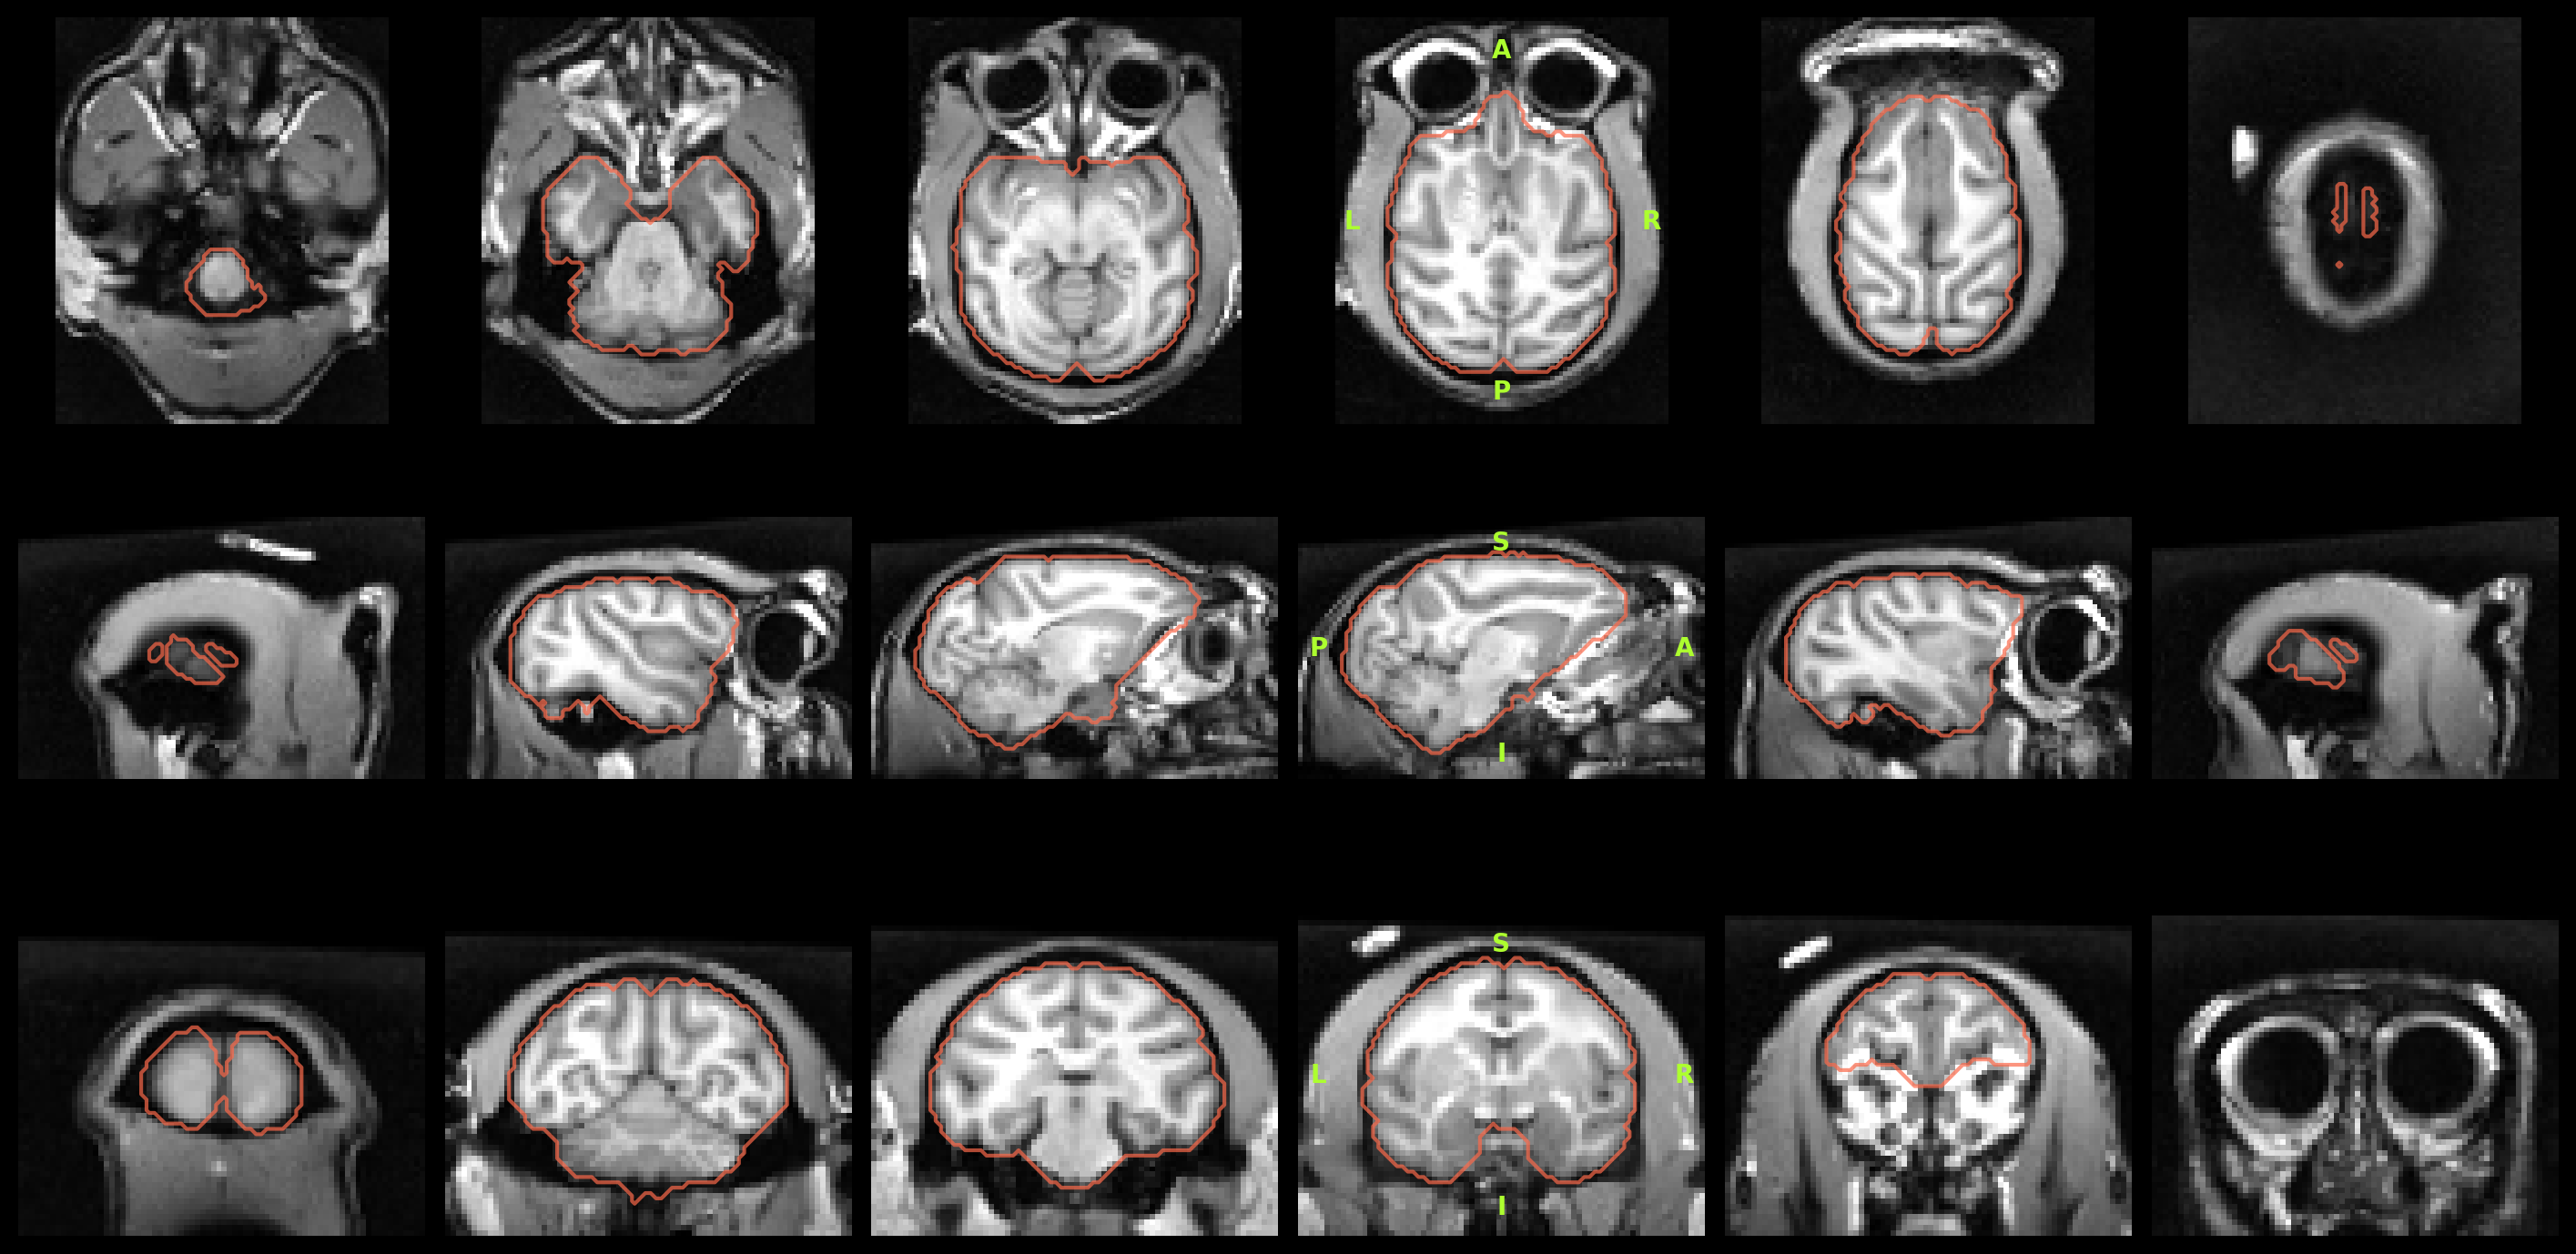

✓ Step 3 — Skull stripping + segmentation  ·  6.2s
  mask=sub-01_space-T1w_desc-brain_mask.nii.gz, seg=sub-01_space-T1w_desc-brain_atlasARM2.nii.gz, lut=sub-01_space-T1w_desc-brain_atlasARM2.tsv



In [10]:
# Step 3 — Skull stripping + segmentation
step_log("Step 3 — Skull stripping + segmentation")
skull_dir = WORK_ROOT / "skullstrip"
skull_dir.mkdir(parents=True, exist_ok=True)

skull_out = anat_skullstripping(
    StepInput(
        input_file=conform_out.output_file,
        working_dir=skull_dir,
        config=config,
        output_name="anat_brain.nii.gz",
        metadata=meta,
    )
)

brain_mask_src = skull_out.additional_files["brain_mask"]
seg_src = skull_out.additional_files.get("segmentation")
atlas_lut_src = skull_out.additional_files.get("atlas_lut")
atlas_name = skull_out.metadata.get("atlas_name", "ARM2")

brain_stripped_file = skull_out.output_file
mask_path = publish_copy(brain_mask_src, f"{bids_prefix_wo_modality}_space-T1w_desc-brain_mask.nii.gz")
if seg_src:
    seg_path = publish_copy(
        seg_src,
        f"{bids_prefix_wo_modality}_space-T1w_desc-brain_atlas{atlas_name}.nii.gz",
    )
if atlas_lut_src:
    lut_path = publish_copy(
        atlas_lut_src,
        f"{bids_prefix_wo_modality}_space-T1w_desc-brain_atlas{atlas_name}.tsv",
    )

skull_qc_png = FIG_DIR / f"{BIDS_PREFIX}_desc-skullstrip_T1w.png"
create_skullstripping_qc(
    underlay_file=str(conformed_file),
    mask_file=str(brain_mask_src),
    save_f=str(skull_qc_png),
    modality="anat",
    logger=qc_logger,
)
show_qc(skull_qc_png, "Skull stripping QC")
_step3_detail = f"mask={mask_path.name}"
if seg_src:
    _step3_detail += f", seg={seg_path.name}"
if atlas_lut_src:
    _step3_detail += f", lut={lut_path.name}"
step_log("Step 3 — Skull stripping + segmentation", done=True, detail=_step3_detail)



▶ Step 4 — Bias correction


2026-06-02 23:09:12 | WARNING  | Workflow: N4 input preparation — clamping 296 negative voxel(s) to 0 (min intensity -8.31178); N4 operates in log domain


Bias correction QC


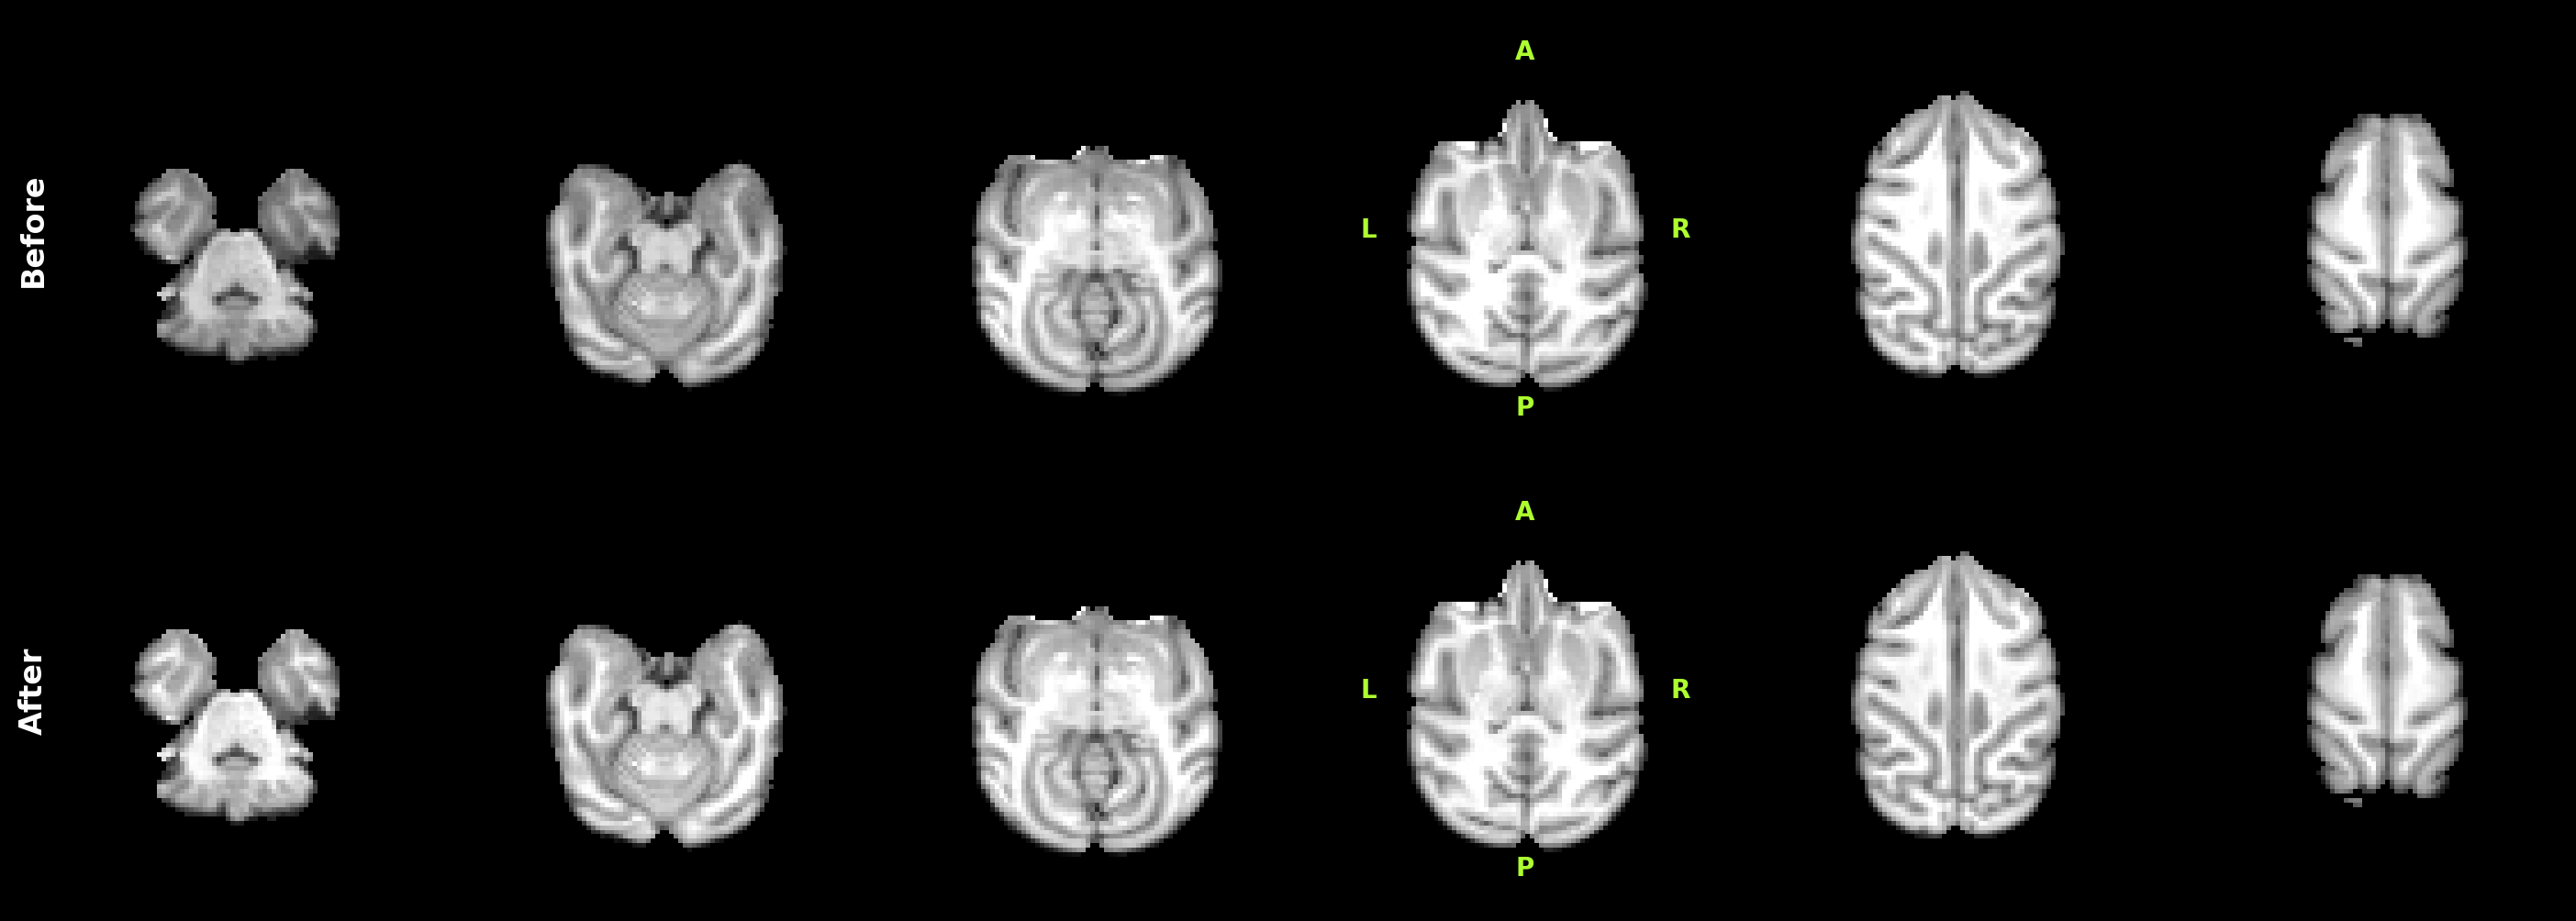

Atlas segmentation QC


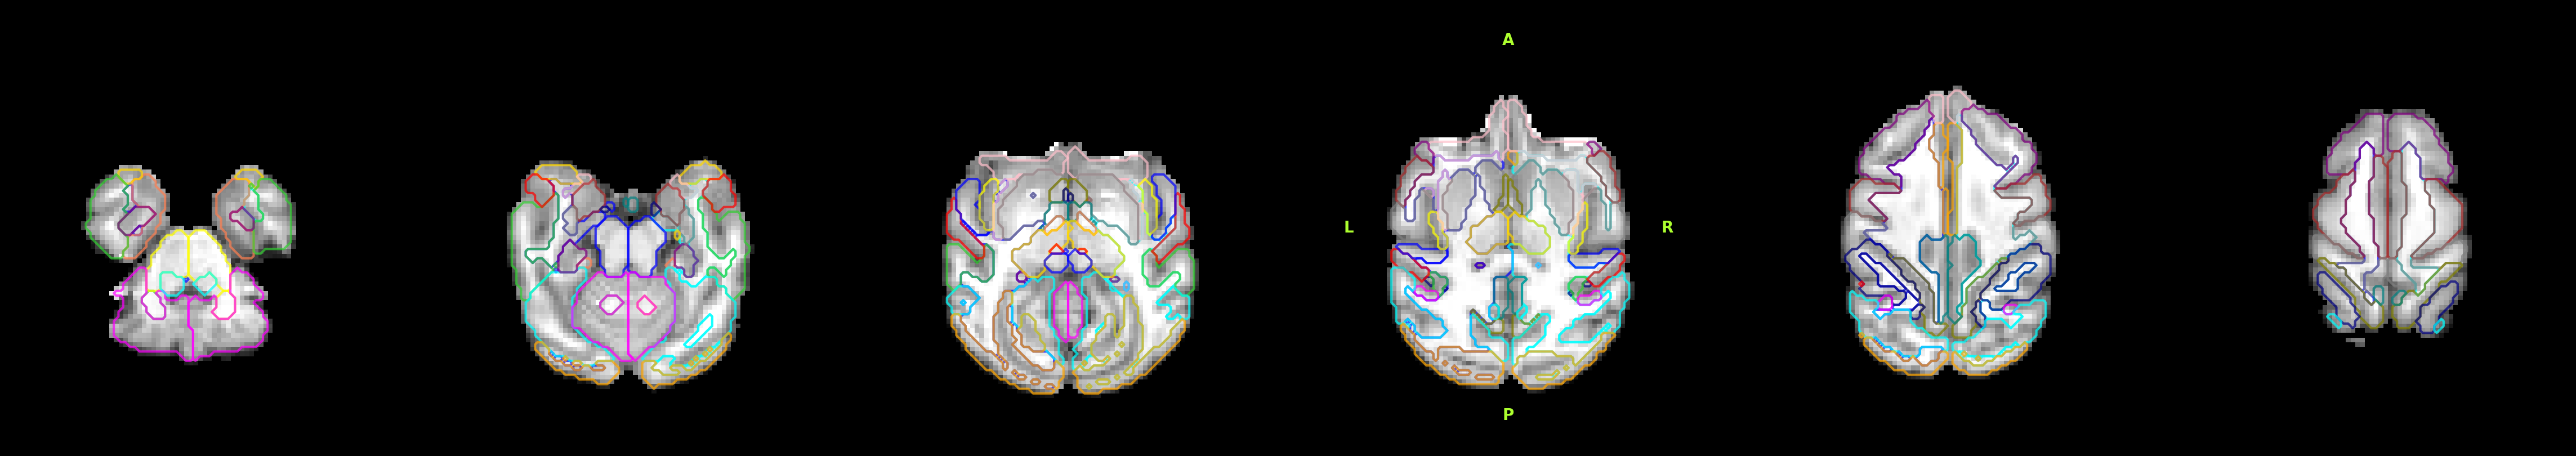

✓ Step 4 — Bias correction  ·  12.4s
  head=anat_bias_corrected.nii.gz, brain=anat_bias_corrected_brain.nii.gz



In [11]:
# Step 4 — Bias correction
step_log("Step 4 — Bias correction")
bias_dir = WORK_ROOT / "bias"
bias_dir.mkdir(parents=True, exist_ok=True)

bias_out = anat_bias_correction(
    StepInput(
        input_file=conform_out.output_file,
        working_dir=bias_dir,
        config=config,
        output_name="anat_bias_corrected.nii.gz",
        metadata=meta,
    ),
    brain_mask=brain_mask_src,
)

bias_head_file = bias_out.output_file
if "brain" in bias_out.additional_files:
    bias_brain_file = bias_out.additional_files["brain"]
else:
    bias_brain_file = bias_out.output_file

bias_qc_png = FIG_DIR / f"{BIDS_PREFIX}_desc-biascorrect_T1w.png"
create_bias_correction_qc(
    image_original=str(brain_stripped_file),
    image_corrected=str(bias_brain_file),
    save_f=str(bias_qc_png),
    modality="anat",
    logger=qc_logger,
)
show_qc(bias_qc_png, "Bias correction QC")

if seg_src:
    seg_qc_png = FIG_DIR / f"{BIDS_PREFIX}_desc-atlasSegmentation_T1w.png"
    create_atlas_segmentation_qc(
        underlay_file=str(bias_brain_file),
        atlas_file=str(seg_path),
        save_f=str(seg_qc_png),
        modality="anat",
        logger=qc_logger,
    )
    show_qc(seg_qc_png, "Atlas segmentation QC")

step_log(
    "Step 4 — Bias correction",
    done=True,
    detail=f"head={bias_head_file.name}, brain={bias_brain_file.name}",
)


In [12]:
# Publish Phase 1 (desc-preproc outputs)
step_log("Publish Phase 1 (T1w desc-preproc)")
preproc_head = publish_copy(
    bias_head_file,
    create_bids_output_filename(bids_name, suffix="space-T1w_desc-preproc", modality=modality),
)
preproc_brain = publish_copy(
    bias_brain_file,
    f"{bids_prefix_wo_modality}_space-T1w_desc-preproc_{modality}_brain.nii.gz",
)

step_log("Publish Phase 1 (T1w desc-preproc)", done=True, detail=f"{preproc_head.name}, {preproc_brain.name}")


▶ Publish Phase 1 (T1w desc-preproc)
✓ Publish Phase 1 (T1w desc-preproc)  ·  0.0s
  sub-01_space-T1w_desc-preproc_T1w.nii.gz, sub-01_space-T1w_desc-preproc_T1w_brain.nii.gz



▶ Step 5 — Registration (brain -> template)


scale: 1, iter: 49/50, loss: -0.956863: 100%|██| 50/50 [00:00<00:00, 254.32it/s]


Rank 0 is acquiring lock
Rank 0 is releasing lock
✓ Step 5 — Registration (brain -> template)  ·  2.2s
  xfm=sub-01_from-T1w_to-NMT2Sym_mode-image_xfm.nii.gz, sub-01_from-NMT2Sym_to-T1w_mode-image_xfm.nii.gz


▶ Step 5 — Apply registration to full head
Registration QC


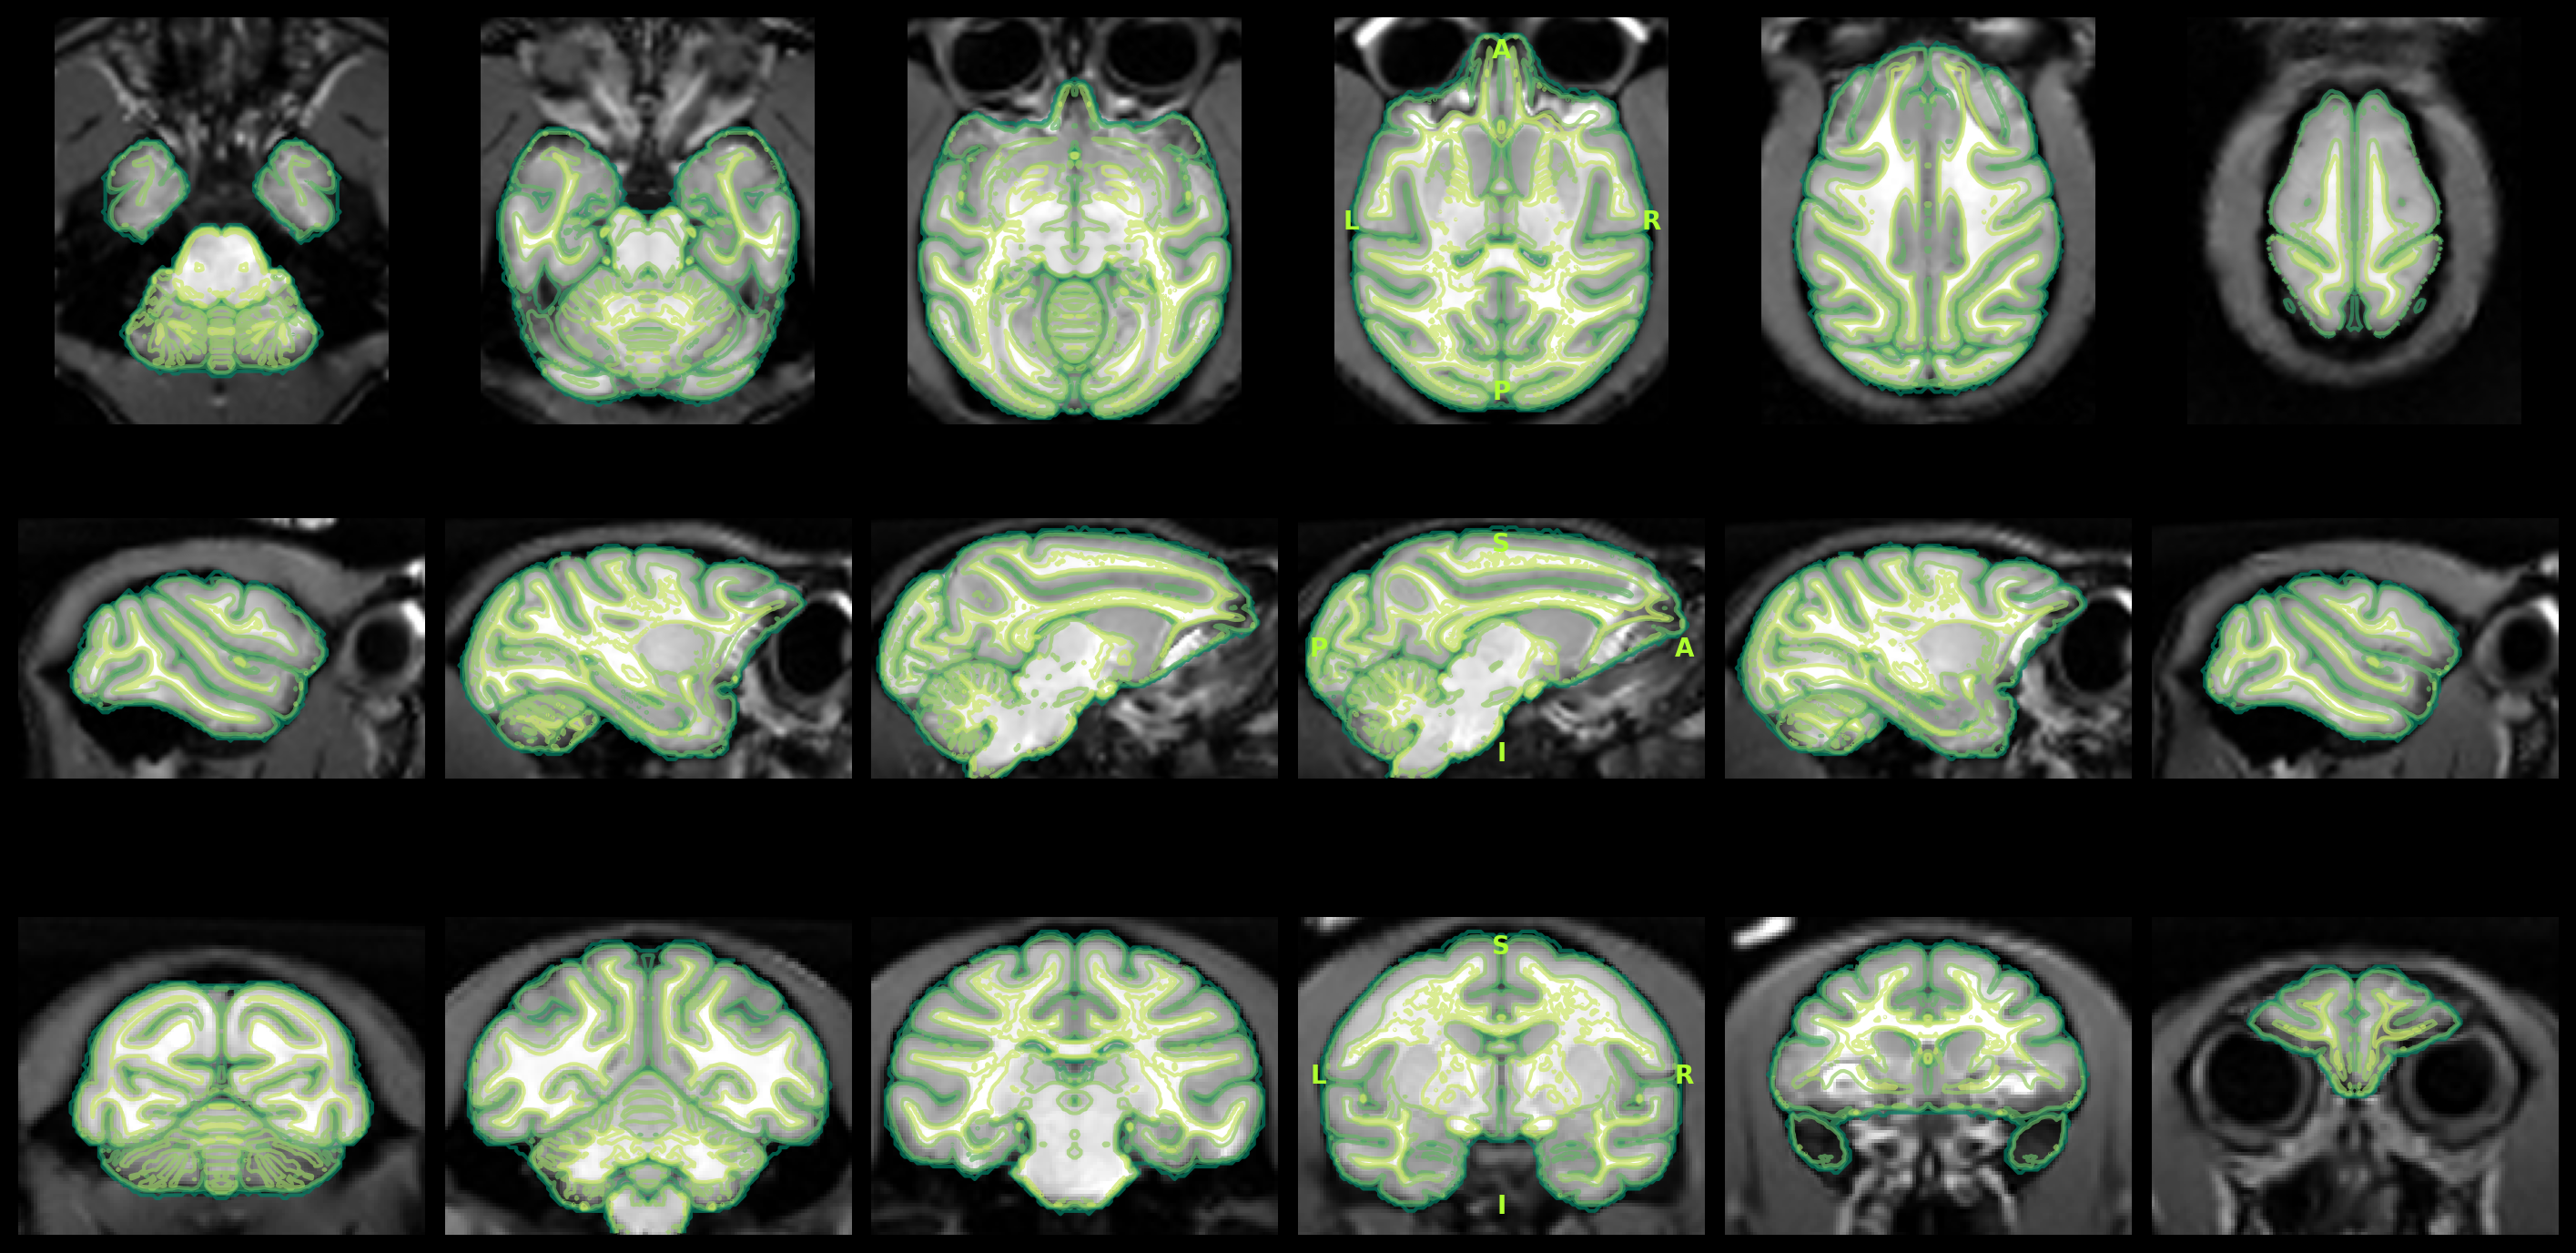

✓ Step 5 — Apply registration to full head  ·  1.6s
  /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy/brainana_lite_output/preproced/sub-01/anat/sub-01_space-NMT2Sym_desc-preproc_T1w.nii.gz



In [13]:
# Step 5 — Registration (brain -> template)
step_log("Step 5 — Registration (brain -> template)")
_reg_cfg = config.get("registration", {})
_uses_fireants = (
    USE_GPU
    and _reg_cfg.get("enable_fireants", True)
    and _reg_cfg.get("anat2template_xfm_type", "syn") == "syn"
)
try:
    import torch

    _uses_fireants = _uses_fireants and torch.cuda.is_available()
except ImportError:
    _uses_fireants = False
if not _uses_fireants:
    tea_time("Registration runs on CPU (antspyx).")

reg_dir = WORK_ROOT / "registration"
reg_dir.mkdir(parents=True, exist_ok=True)

# register bias-corrected brain
reg_brain_out = anat_registration(
    StepInput(
        input_file=bias_brain_file,
        working_dir=reg_dir,
        config=config,
        output_name="anat_registered_brain.nii.gz",
        metadata=meta,
    ),
    template_file=template_file,
    template_name=TEMPLATE,
)

forward_xfm = reg_brain_out.additional_files["forward_transform"]
inverse_xfm = reg_brain_out.additional_files["inverse_transform"]

# Publish registration xfms (extension from _xfm_ext).
reg_xfm_published = []
fwd_xfm_path = publish_copy(
    forward_xfm,
    f"{bids_prefix_wo_modality}_from-{modality}_to-{TEMPLATE}_mode-image_xfm{_xfm_ext(forward_xfm)}",
)
reg_xfm_published.append(fwd_xfm_path.name)
inv_xfm_path = publish_copy(
    inverse_xfm,
    f"{bids_prefix_wo_modality}_from-{TEMPLATE}_to-{modality}_mode-image_xfm{_xfm_ext(inverse_xfm)}",
)
reg_xfm_published.append(inv_xfm_path.name)
step_log(
    "Step 5 — Registration (brain -> template)",
    done=True,
    detail=f"xfm={', '.join(reg_xfm_published)}",
)

step_log("Step 5 — Apply registration to full head")
interpolation = config.get("registration", {}).get("interpolation", "BSpline")
apply_result = ants_apply_transforms(
    movingf=str(bias_head_file),
    moving_type=0,
    interpolation=interpolation,
    outputf_name="anat_registered_head.nii.gz",
    fixedf=str(template_file),
    working_dir=str(reg_dir / "apply_head"),
    transformf=[str(forward_xfm)],
    reff=str(template_file),
    logger=qc_logger,
)

registered_head = Path(apply_result["imagef_registered"])
reg_head_path = publish_copy(
    registered_head,
    create_bids_output_filename(
        bids_name,
        suffix=f"space-{TEMPLATE}_desc-preproc",
        modality=modality,
    ),
)

reg_qc_png = FIG_DIR / f"{BIDS_PREFIX}_desc-anat2template_T1w.png"
create_registration_qc(
    image_file=str(reg_head_path),
    template_file=str(template_file),
    save_f=str(reg_qc_png),
    modality="anat2template",
    logger=qc_logger,
)
show_qc(reg_qc_png, "Registration QC")
step_log("Step 5 — Apply registration to full head", done=True, detail=str(reg_head_path))


In [14]:
# Apply brain mask to template space
step_log("Apply brain mask to template space")
mask_reg_dir = WORK_ROOT / "mask_to_template"
mask_reg_dir.mkdir(parents=True, exist_ok=True)

mask_apply = ants_apply_transforms(
    movingf=str(brain_mask_src),
    moving_type=0,
    interpolation="NearestNeighbor",
    outputf_name="mask_registered.nii.gz",
    fixedf=str(template_file),
    working_dir=str(mask_reg_dir),
    transformf=[str(forward_xfm)],
    reff=str(template_file),
    logger=qc_logger,
    generate_tmean=False,
)

mask_registered = Path(mask_apply["imagef_registered"])
mask_template_name = f"{replace_bids_space(bids_prefix_wo_modality, TEMPLATE)}_desc-brain_mask.nii.gz"
mask_template_path = publish_copy(mask_registered, mask_template_name)
step_log("Apply brain mask to template space", done=True, detail=str(mask_template_path))


▶ Apply brain mask to template space
✓ Apply brain mask to template space  ·  0.2s
  /mnt/DataDrive3/xliu/prep_test/test_brainana_lite/example_for_brainana_lite_easy/brainana_lite_output/preproced/sub-01/anat/sub-01_space-NMT2Sym_desc-brain_mask.nii.gz


In [15]:
# Step 6 — Atlas backproject to T1w space
step_log("Step 6 — Atlas backproject to T1w space")
atlas_t1w_dir = WORK_ROOT / "atlas_t1w"
atlas_t1w_dir.mkdir(parents=True, exist_ok=True)

bp_out = anat_backproject_atlases(
    inverse_xfm=inverse_xfm,
    t1w_reference=preproc_head,
    bids_name=bids_name,
    working_dir=atlas_t1w_dir,
    config=config,
    template_dir=None,
)

atlas_t1w_pub = ANAT_DIR / "atlas_space-T1w"
atlas_t1w_pub.mkdir(parents=True, exist_ok=True)
atlas_t1w_files = []
for atlas_name_key, atlas_path in bp_out.additional_files.items():
    dst = atlas_t1w_pub / atlas_path.name
    shutil.copy2(atlas_path, dst)
    atlas_t1w_files.append(dst)
    print(f"  T1w atlas: {dst.name}")

step_log("Step 6 — Atlas backproject to T1w space", done=True, detail=f"{len(atlas_t1w_files)} atlas(es)")



▶ Step 6 — Atlas backproject to T1w space
  T1w atlas: atlas-ARM1_space-T1w_sub-01.nii.gz
  T1w atlas: atlas-ARM2_space-T1w_sub-01.nii.gz
  T1w atlas: atlas-ARM3_space-T1w_sub-01.nii.gz
  T1w atlas: atlas-ARM4_space-T1w_sub-01.nii.gz
  T1w atlas: atlas-ARM5_space-T1w_sub-01.nii.gz
  T1w atlas: atlas-ARM6_space-T1w_sub-01.nii.gz
  T1w atlas: atlas-CortHierarchy_space-T1w_sub-01.nii.gz
  T1w atlas: atlas-D99_space-T1w_sub-01.nii.gz
  T1w atlas: atlas-FuncNetwork_space-T1w_sub-01.nii.gz
  T1w atlas: atlas-MacBNA_space-T1w_sub-01.nii.gz
✓ Step 6 — Atlas backproject to T1w space  ·  1.1s
  10 atlas(es)



In [16]:
# Step 7 — Atlas to scanner space
step_log("Step 7 — Atlas reprojection to scanner space")
atlas_scanner_dir = WORK_ROOT / "atlas_scanner"
atlas_scanner_dir.mkdir(parents=True, exist_ok=True)

conform_inverse = conform_out.additional_files.get("inverse_transform")
if conform_inverse is None:
    raise FileNotFoundError("Conform inverse transform not found")

scanner_out = anat_reproject_atlases_to_scanner(
    atlas_files=atlas_t1w_files,
    conform_inverse_xfm=conform_inverse,
    scanner_reference=synth_file,
    working_dir=atlas_scanner_dir,
    rigid_method="sitk",
)

atlas_scanner_pub = ANAT_DIR / "atlas_space-scanner"
atlas_scanner_pub.mkdir(parents=True, exist_ok=True)
for _, atlas_path in scanner_out.additional_files.items():
    dst = atlas_scanner_pub / Path(atlas_path).name
    shutil.copy2(atlas_path, dst)
    print(f"  Scanner atlas: {dst.name}")

step_log("Step 7 — Atlas reprojection to scanner space", done=True)



▶ Step 7 — Atlas reprojection to scanner space
  Scanner atlas: atlas-ARM1_space-scanner_sub-01.nii.gz
  Scanner atlas: atlas-ARM2_space-scanner_sub-01.nii.gz
  Scanner atlas: atlas-ARM3_space-scanner_sub-01.nii.gz
  Scanner atlas: atlas-ARM4_space-scanner_sub-01.nii.gz
  Scanner atlas: atlas-ARM5_space-scanner_sub-01.nii.gz
  Scanner atlas: atlas-ARM6_space-scanner_sub-01.nii.gz
  Scanner atlas: atlas-CortHierarchy_space-scanner_sub-01.nii.gz
  Scanner atlas: atlas-D99_space-scanner_sub-01.nii.gz
  Scanner atlas: atlas-FuncNetwork_space-scanner_sub-01.nii.gz
  Scanner atlas: atlas-MacBNA_space-scanner_sub-01.nii.gz
✓ Step 7 — Atlas reprojection to scanner space  ·  0.3s



In [17]:
# Output summary
if ON_DRIVE_FUSE:
    step_log("Sync results to Google Drive")
    sync_process_dir_to_drive()
    step_log("Sync results to Google Drive", done=True, detail=str(WORKING_DIR))

step_log("Output summary")
print("\nPreproced tree:")
preproced_root = OUTPUT_DIR / "preproced"
for root, dirs, files in os.walk(preproced_root):
    dirs[:] = [d for d in dirs if not d.startswith("_")]
    level = Path(root).relative_to(preproced_root).parts
    indent = "  " * len(level)
    print(f"{indent}{Path(root).name}/")
    for fname in sorted(files):
        print(f"{indent}  {fname}")

step_log("Output summary", done=True)
print("\nDone.")


▶ Output summary

Preproced tree:
preproced/
  sub-01/
    figures/
      sub-01_desc-anat2template_T1w.png
      sub-01_desc-atlasSegmentation_T1w.png
      sub-01_desc-biascorrect_T1w.png
      sub-01_desc-conform_T1w.png
      sub-01_desc-skullstrip_T1w.png
    anat/
      sub-01_from-NMT2Sym_to-T1w_mode-image_xfm.nii.gz
      sub-01_from-T1w_to-NMT2Sym_mode-image_xfm.nii.gz
      sub-01_from-T1w_to-scanner_mode-image_xfm.mat
      sub-01_from-scanner_to-T1w_mode-image_xfm.mat
      sub-01_space-NMT2Sym_desc-brain_mask.nii.gz
      sub-01_space-NMT2Sym_desc-preproc_T1w.nii.gz
      sub-01_space-T1w_desc-brain_atlasARM2.nii.gz
      sub-01_space-T1w_desc-brain_atlasARM2.tsv
      sub-01_space-T1w_desc-brain_mask.nii.gz
      sub-01_space-T1w_desc-preproc_T1w.nii.gz
      sub-01_space-T1w_desc-preproc_T1w_brain.nii.gz
      sub-01_space-scanner_T1w.nii.gz
      atlas_space-T1w/
        atlas-ARM1_space-T1w_sub-01.nii.gz
        atlas-ARM2_space-T1w_sub-01.nii.gz
        atlas-ARM3_spa